# 03. GTX-A 역 거리와 광역버스 승차인원 변화량

H3 8 공급구조 유지 셀을 대상으로 GTX-A 역과의 거리와 광역버스 승차인원 변화량의 상관관계 및 거리구간별 변화를 분석한다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h3
from scipy.stats import pearsonr, spearmanr

plt.rcParams['font.family'] = ['Malgun Gothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
BASE = Path.cwd()
if BASE.name == 'Analysis': BASE = BASE.parent
OUTPUT_DIR = BASE / 'Analysis' / 'output'
stable = pd.read_csv(OUTPUT_DIR / 'h3_8_stable_supply_demand_change.csv', encoding='utf-8-sig')
print(f'분석 셀 수: {len(stable)}개')
display(stable.head())

분석 셀 수: 71개


,H3 셀,2024 승차인원,2025 승차인원,승차인원 증감
0,8830e0a407fffff,9,14,5
1,8830e0a419fffff,31,11,-20
2,8830e0a41dfffff,211,165,-46
3,8830e0a423fffff,14,8,-6
4,8830e0a42bfffff,25,10,-15


In [2]:
gtx_stations = pd.DataFrame({'역명': ['운정중앙', '킨텍스', '대곡'], 'lat': [37.716670, 37.665000, 37.631626], 'lon': [126.728330, 126.748060, 126.811024]})
def h3_center(cell):
    return h3.cell_to_latlng(cell) if hasattr(h3, 'cell_to_latlng') else h3.h3_to_geo(cell)
def haversine_km(lat1, lon1, lat2, lon2):
    radius = 6371.0088
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dlat, dlon = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dlat / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlon / 2) ** 2
    return 2 * radius * np.arcsin(np.sqrt(a))
centers = stable['H3 셀'].map(h3_center)
stable[['셀 중심 위도', '셀 중심 경도']] = pd.DataFrame(centers.tolist(), index=stable.index)
distance_matrix = pd.DataFrame({station['역명']: haversine_km(stable['셀 중심 위도'], stable['셀 중심 경도'], station['lat'], station['lon']) for _, station in gtx_stations.iterrows()})
stable['최근접 GTX-A역'] = distance_matrix.idxmin(axis=1)
stable['최근접 GTX-A역 거리(km)'] = distance_matrix.min(axis=1)
display(stable[['H3 셀', '최근접 GTX-A역', '최근접 GTX-A역 거리(km)', '승차인원 증감']].head())

,H3 셀,최근접 GTX-A역,최근접 GTX-A역 거리(km),승차인원 증감
0,8830e0a407fffff,대곡,1.202172,5
1,8830e0a419fffff,대곡,3.096557,-20
2,8830e0a41dfffff,대곡,2.365996,-46
3,8830e0a423fffff,대곡,1.905106,-6
4,8830e0a42bfffff,대곡,1.132523,-15


## 상관분석

승차인원 변화량은 `2025년 승차인원 − 2024년 승차인원`으로 계산한다. Pearson과 Spearman을 함께 산출하고, 그래프에는 Spearman 결과를 표시한다.

,승차인원 지표,표본 수,Pearson 상관계수,Pearson p-value,Spearman 상관계수,Spearman p-value
0,승차인원 증감,71,0.247,0.038,0.391,0.001


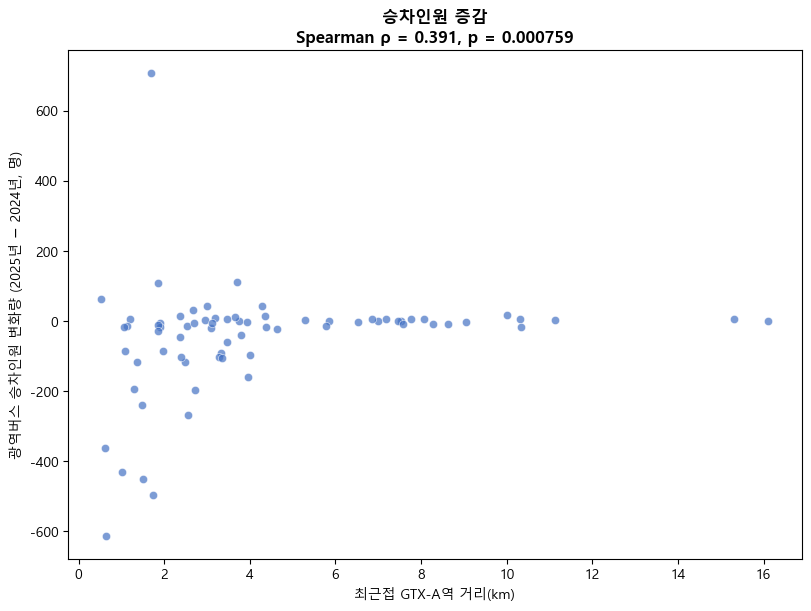

In [3]:
distance_col = '최근접 GTX-A역 거리(km)'
demand_cols = ['승차인원 증감']
Y_LABEL = '광역버스 승차인원 변화량 (2025년 − 2024년, 명)'
rows = []
for col in demand_cols:
    pair = stable[[distance_col, col]].dropna()
    pearson_r, pearson_p = pearsonr(pair[distance_col], pair[col])
    spearman_r, spearman_p = spearmanr(pair[distance_col], pair[col])
    rows.append({'승차인원 지표': col, '표본 수': len(pair), 'Pearson 상관계수': pearson_r, 'Pearson p-value': pearson_p, 'Spearman 상관계수': spearman_r, 'Spearman p-value': spearman_p})
correlation_summary = pd.DataFrame(rows)
display(correlation_summary.round(3))
for col in demand_cols:
    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
    sns.scatterplot(data=stable, x=distance_col, y=col, ax=ax, s=35, alpha=0.7, color='#4472C4')
    r, p = spearmanr(stable[distance_col], stable[col])
    ax.set_title(f'{col}\nSpearman ρ = {r:.3f}, p = {p:.3g}', fontweight='bold')
    ax.set_xlabel('최근접 GTX-A역 거리(km)')
    ax.set_ylabel(Y_LABEL)
    plt.show()

## GTX-A 역 거리구간별 변화량 비교

상관계수의 방향을 실제 감소·증가 현상으로 확인하기 위해 거리구간별 승차인원 변화량 중앙값과 감소·증가 셀 비율을 비교한다.

In [4]:
distance_bins = [0, 2, 5, 10, np.inf]
distance_labels = ['0~2 km', '2~5 km', '5~10 km', '10 km 이상']
stable['GTX-A 거리구간'] = pd.cut(stable[distance_col], bins=distance_bins, labels=distance_labels, right=False, include_lowest=True)
distance_band_rows = []
for band, group in stable.groupby('GTX-A 거리구간', observed=False):
    change = group['승차인원 증감']
    distance_band_rows.append({'GTX-A 거리구간': str(band), '셀 수': len(group), '승차인원 변화량 중앙값': change.median(), '감소 셀 수': int((change < 0).sum()), '감소 비율(%)': (change < 0).mean() * 100, '변화 없음 셀 수': int((change == 0).sum()), '증가 셀 수': int((change > 0).sum()), '증가 비율(%)': (change > 0).mean() * 100})
distance_band_summary = pd.DataFrame(distance_band_rows)
display(distance_band_summary.round(1))

,GTX-A 거리구간,셀 수,승차인원 변화량 중앙값,감소 셀 수,감소 비율(%),변화 없음 셀 수,증가 셀 수,증가 비율(%)
0,0~2 km,20,-57.0,16,80.0,0,4,20.0
1,2~5 km,30,-15.5,19,63.3,0,11,36.7
2,5~10 km,16,0.0,7,43.8,2,7,43.8
3,10 km 이상,5,3.0,1,20.0,0,4,80.0
